### 3.2 Assignment: Using Data to Improve MLB Attendance
### Author: Nicholas Stirling
### Due Date: 12/21/25
#### Description: This assignment uses data on the Los Angeles Dodgers Major League Baseball (MLB) team The data will be used to make a recommendation to management on how to improve attendance. Tell a story with the analysis and clearly explain the steps taken to arrive at that conclusion.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("dodgers-2022.csv")

print(df.head())
df.info()

  month  day  attend day_of_week opponent  temp   skies day_night cap shirt  \
0   APR   10   56000     Tuesday  Pirates    67  Clear        Day  NO    NO   
1   APR   11   29729   Wednesday  Pirates    58  Cloudy     Night  NO    NO   
2   APR   12   28328    Thursday  Pirates    57  Cloudy     Night  NO    NO   
3   APR   13   31601      Friday   Padres    54  Cloudy     Night  NO    NO   
4   APR   14   46549    Saturday   Padres    57  Cloudy     Night  NO    NO   

  fireworks bobblehead  
0        NO         NO  
1        NO         NO  
2        NO         NO  
3       YES         NO  
4        NO         NO  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   month        81 non-null     object
 1   day          81 non-null     int64 
 2   attend       81 non-null     int64 
 3   day_of_week  81 non-null     object
 4   opponent     81 non-n

Upon initial inspection of the loaded file, attendance is already a proper data type and there are no missing fields in any of the columns.

Initially, I will review the days of the week to see which days historically have the lower attendance. In order to do this I will calculate the average attendeance per day of the week. I will compare these using a bar chart as that will make it easy to interpret and potential communication to management later on for the identified recommendation. I am expecting that weekday games are likely to have lower attendance then weekends.

day_of_week
Monday       34965.666667
Wednesday    37585.166667
Friday       40116.923077
Thursday     40407.400000
Sunday       42268.846154
Saturday     43072.923077
Tuesday      47741.230769
Name: attend, dtype: float64


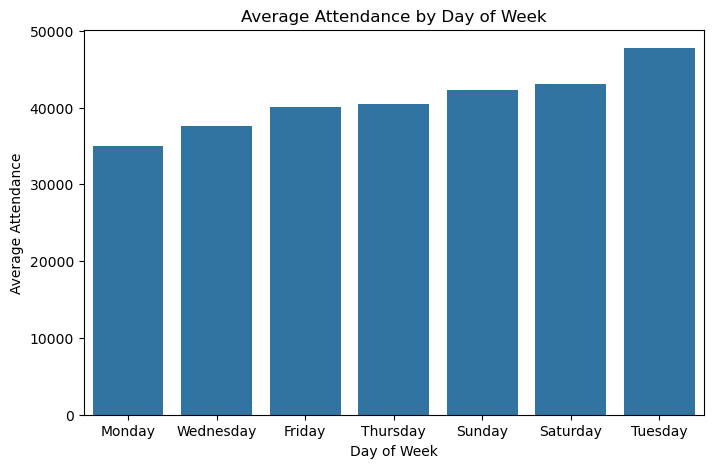

In [3]:
day_attendance = (df.groupby("day_of_week")["attend"].mean().sort_values())

print(day_attendance)

plt.figure(figsize=(8,5))
sns.barplot(
    x=day_attendance.index,
    y=day_attendance.values
)

plt.title("Average Attendance by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Attendance")
plt.show()

Suprisingly Tuesday is actually the highest average attendance day for games, followed by the weekend games. Monday and Wednesday are lower on average by quite a margin and are the strongest candidates to be targeted for promotional strategies to boost attendance.

Next, I want to evaluate whether the promotional columns (assumed to be giveaways/entertainment) actually move the needle. I will compare the average attendance when each promotion is present vs that when it is absent. This should help identify which if any promotions are the most effective.

In [6]:
# Select the promotional columns
promo_cols = ["cap", "shirt", "fireworks", "bobblehead"]

# Create an empty dictionary to hold the promotional details
promo_attendance = {}

# For each promotion determine the mean attendance and store in the dictionary
for promo in promo_cols:
    promo_attendance[promo] = df.groupby(promo)["attend"].mean()

promo_attendance_df = pd.DataFrame(promo_attendance)
promo_attendance_df

,cap,shirt,fireworks,bobblehead
NO,41112.240506,40824.551282,41032.179104,39137.928571
YES,38189.500000,46643.666667,41077.857143,53144.636364


Based on the displayed information it would appear that bobbleheads have the greatest impact and fireworks the least based on quick comparison between NO (promotion not available) and YES (promotion available) mean values. One thing of note is these values do not compare only to days where no promotions are present, only days when that specific promotion is not available. It is also possible more detailed review for combinations of promotion could lead to increased attendance impact.

To make the promotion information easier to interpret and visualize the above comparisons boxplots will be created for each promotion. This will allow me to see the averages but also variability and possible outliers.

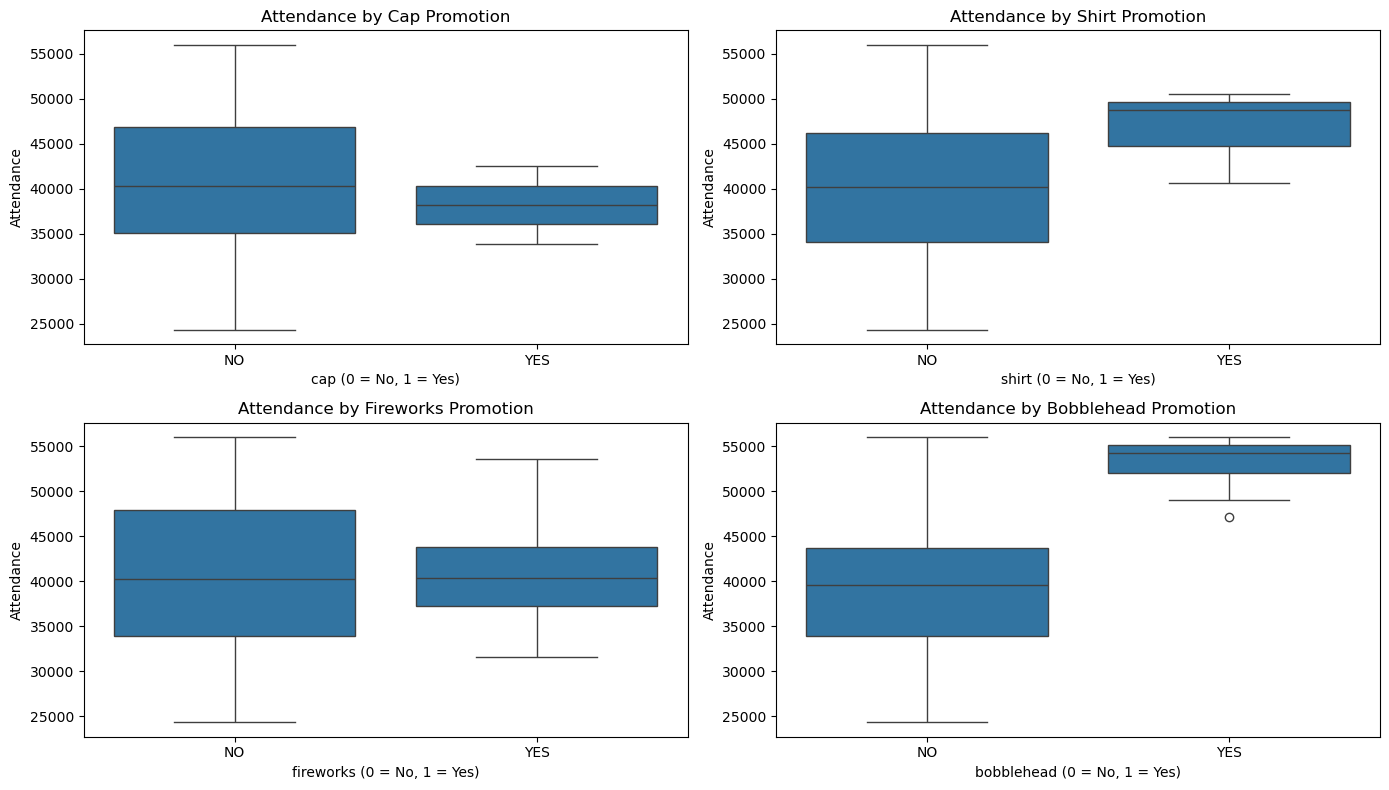

In [7]:
plt.figure(figsize=(14,8))

for i, promo in enumerate(promo_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(
        data=df,
        x=promo,
        y="attend"
    )
    plt.title(f"Attendance by {promo.capitalize()} Promotion")
    plt.xlabel(f"{promo} (0 = No, 1 = Yes)")
    plt.ylabel("Attendance")

plt.tight_layout()
plt.show()

Based on the boxplots, it becomes clear bobbleheads relate to the strongest attendance and has low variance compared to the other promotions. It also shows the cap promotions while having less overall variance then when there is no promotion is actually associated with a lower average attendance. For presentation to management I would not want to use boxplots but bar charts to emphasize the potential gain the promotions offer to attendance.

            Attendance Lift
bobblehead     14006.707792
shirt           5819.115385
fireworks         45.678038
cap            -2922.740506


C:\Users\Laurie\AppData\Local\Temp\ipykernel_35312\2237726577.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  promo_effect[promo] = means[1] - means[0]
C:\Users\Laurie\AppData\Local\Temp\ipykernel_35312\2237726577.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  promo_effect[promo] = means[1] - means[0]
C:\Users\Laurie\AppData\Local\Temp\ipykernel_35312\2237726577.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  promo_effe

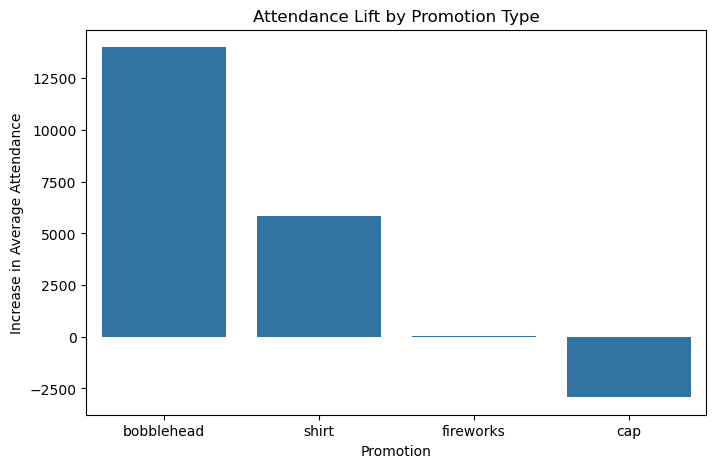

In [9]:
# Create an empty dictionary for the promotional effect calculations
promo_effect = {}

# For the calculated means find the difference between when the promotion is present and those without
for promo in promo_cols:
    means = df.groupby(promo)["attend"].mean()
    promo_effect[promo] = means[1] - means[0]

promo_effect_df = (
    pd.DataFrame.from_dict(promo_effect, orient="index", columns=["Attendance Lift"])
    .sort_values(by="Attendance Lift", ascending=False)
)

print(promo_effect_df)

# Create bar chart
plt.figure(figsize=(8,5))
sns.barplot(
    x=promo_effect_df.index,
    y=promo_effect_df["Attendance Lift"]
)

plt.title("Attendance Lift by Promotion Type")
plt.xlabel("Promotion")
plt.ylabel("Increase in Average Attendance")
plt.show()

This creates a very clear picture of the difference in the different promotions and the average differences that will really drive home the pitch to management.

#### Data-Driven Recommendation to Improve Game Attendance

Based on exploratory data analysis of the 2022 Dodgerts attendance data, the below summarizes key findings and provides a data-driven recommendation to improve game attendance through targeted promotion strategies.

##### Summary of Analysis
The analysis focused on evaluating the attendance patterns by the day of the week and the impact of promotional campaigns, specifically caps, shirts, fireworks, and bobbleheads. Average attendance was calculated across days and compared between game with and without each promotion to identify which strategies were the most effective at driving turnout.

It was identified that Monday and Wednesday games consistently had lower average attendance relative to other days of the week. These days represent the greatest opportunity for improvement leveraging promotional strategies. These could lead to incrementatl increases that would yield meaningful gains without competing against already high demand games. Among the promotional variables analyzed bobblehead giveawayes produced the highest attendance lift. Games with bobblehead promotions showed a clear and substantial increase in average attendance compared to games without the promotion. The other promotions shows more modest or inconsistent results.

##### Recommendation
Based on these findings, I am recommending that we prioritize bobblehead giveaway promotions as the primary promotion strategy given their demonstrated ability to significantly increase attendance. These promotions should be targeted for Monday and Wednesday games, as they represent the lowest baseline attendance and therefore have the highest potential return on the promotion investment. Marketing and communication efforts would need to align around these targeted promotional games to maximize awareness and impact.

This focused approach allows the organization to deploy promotional resources more efficiently while addressing specific segments of the schedule where attendance were underperforming and gains are more achievable.